In [2]:
from ctlearn_manager import CTLearnModelManager, DataSample
from ctlearn_manager.utils import remove_model_from_index
import astropy.units as u
import numpy as np
import pandas as pd

# 🧠 Create new `CTLearnModelManager`
`CTLearnModelManager` is an object that allows you to setup and train a CTLearn model

In [ ]:
def get_surrounding_nodes(index, nodes, num_surrounding=1):
    surrounding_indices = []
    for i in range(1, num_surrounding + 1):
        if index - i >= 0:
            surrounding_indices.append(index - i)
        if index + i < len(nodes):
            surrounding_indices.append(index + i)
        if len(surrounding_indices) >= num_surrounding:
            break
    return surrounding_indices

type_ze37.661_az270.641_ze30.390_az266.360
❌ Model nickname LST1_type_CRABdec_0 already in table
🧠 Model name: LST1_type_CRABdec_0


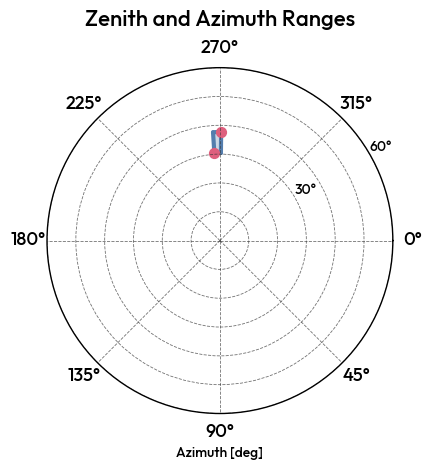

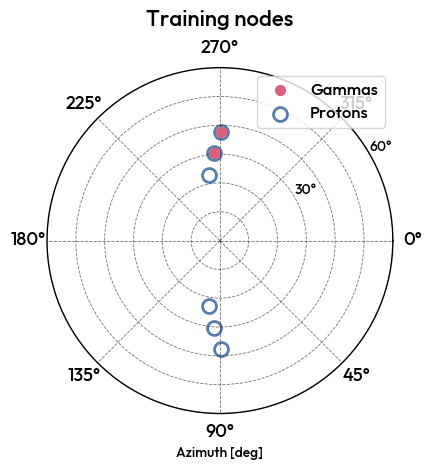

type_ze30.390_az266.360_ze23.161_az260.739
❌ Model nickname LST1_type_CRABdec_1 already in table
🧠 Model name: LST1_type_CRABdec_1


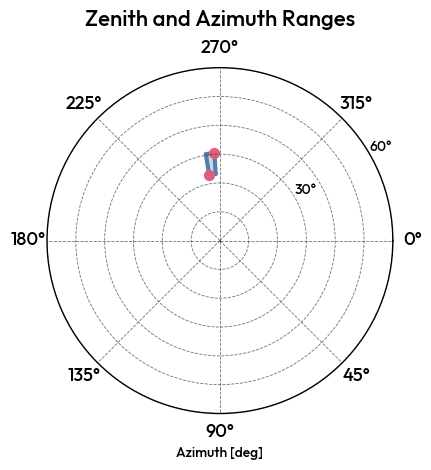

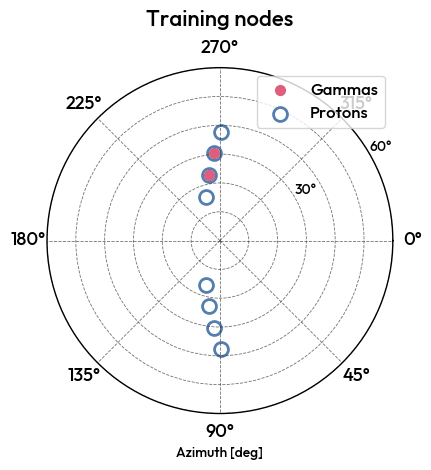

type_ze23.161_az260.739_ze16.087_az251.910
❌ Model nickname LST1_type_CRABdec_2 already in table
🧠 Model name: LST1_type_CRABdec_2


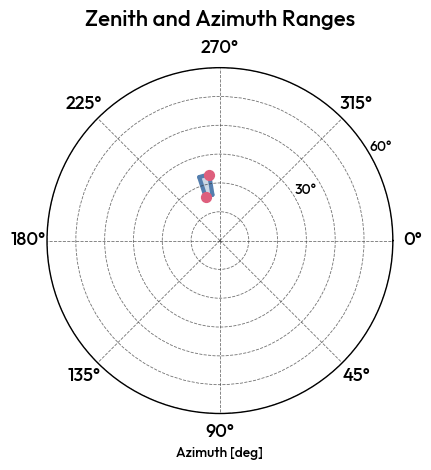

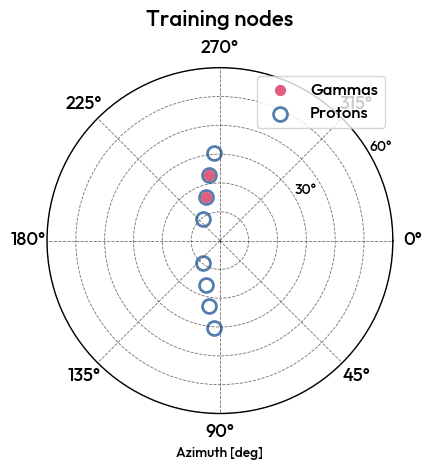

type_ze16.087_az251.910_ze9.579_az233.112
❌ Model nickname LST1_type_CRABdec_3 already in table
🧠 Model name: LST1_type_CRABdec_3


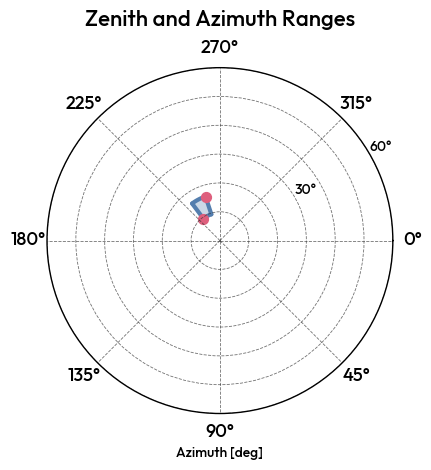

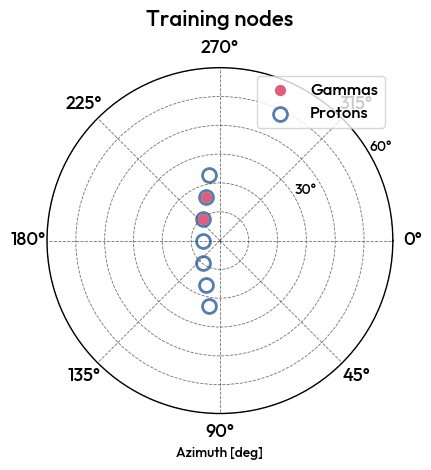

type_ze9.579_az233.112_ze6.000_az180.000
❌ Model nickname LST1_type_CRABdec_4 already in table
🧠 Model name: LST1_type_CRABdec_4


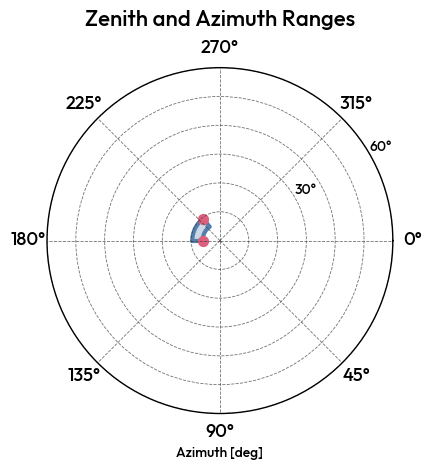

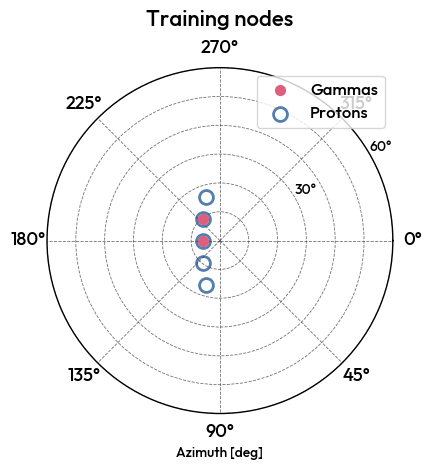

type_ze6.000_az180.000_ze9.579_az126.888
❌ Model nickname LST1_type_CRABdec_5 already in table
🧠 Model name: LST1_type_CRABdec_5


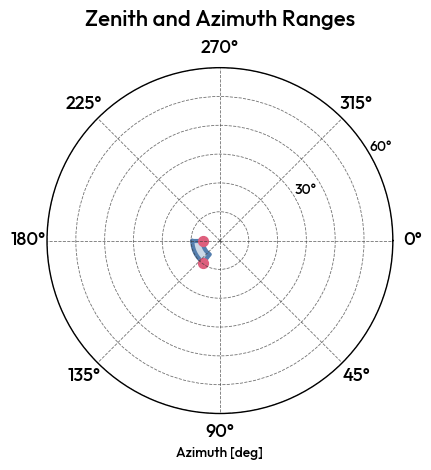

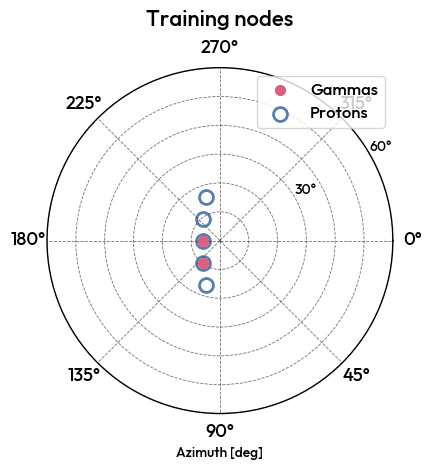

type_ze9.579_az126.888_ze16.087_az108.090
❌ Model nickname LST1_type_CRABdec_6 already in table
🧠 Model name: LST1_type_CRABdec_6


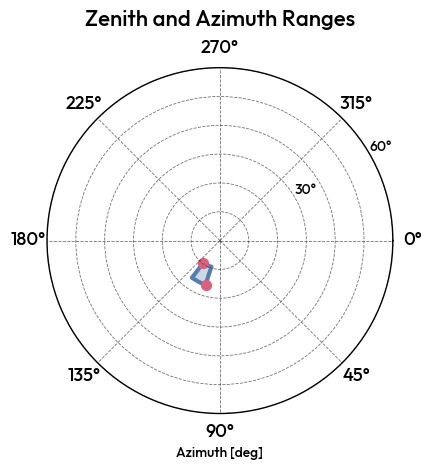

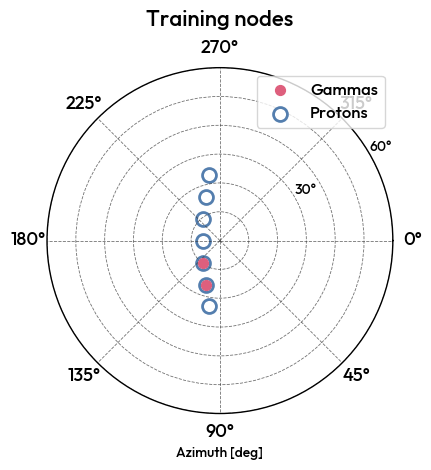

type_ze16.087_az108.090_ze23.161_az99.261
❌ Model nickname LST1_type_CRABdec_7 already in table
🧠 Model name: LST1_type_CRABdec_7


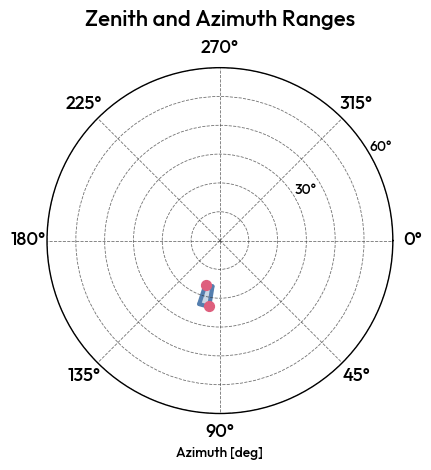

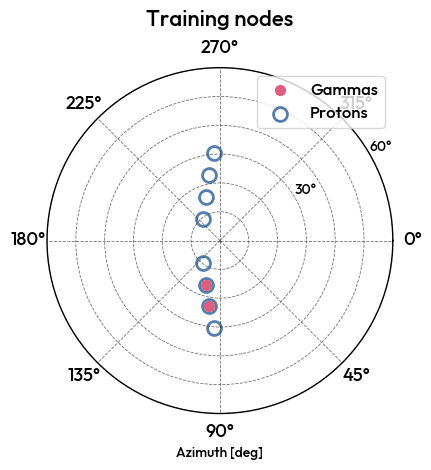

type_ze23.161_az99.261_ze30.390_az93.640
❌ Model nickname LST1_type_CRABdec_8 already in table
🧠 Model name: LST1_type_CRABdec_8


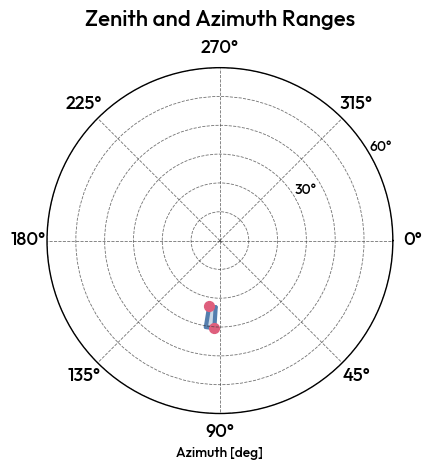

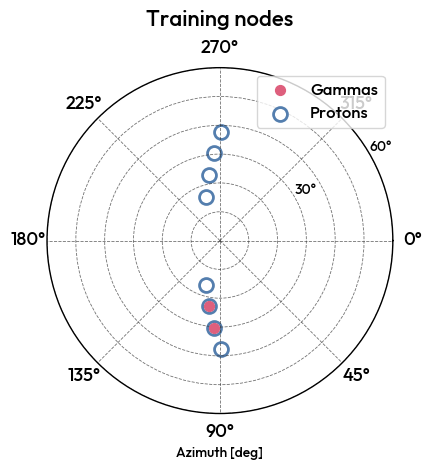

type_ze30.390_az93.640_ze37.661_az89.359
❌ Model nickname LST1_type_CRABdec_9 already in table
🧠 Model name: LST1_type_CRABdec_9


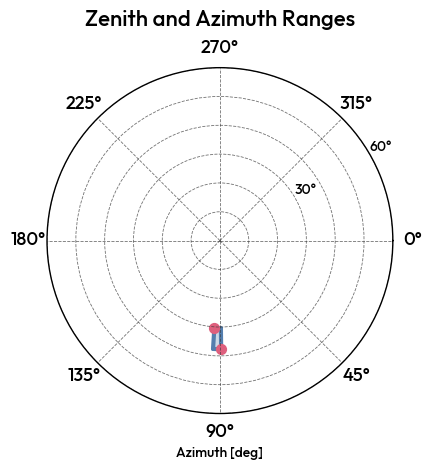

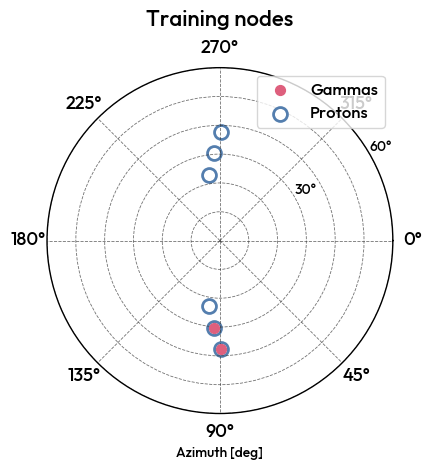

In [ ]:
# first_node_index = 0 # [0..9]
reco = 'cameradirection' # 'energy', 'type', 'cameradirection', 'skydirection'
for i in range(10):
    first_node_index = i
    training_nodes_gammas = pd.read_csv('/users/blacave/PhD/LST/CTLearnManager/TrainingNodesGammaDiffuse.csv')
    training_nodes_protons = pd.read_csv('/users/blacave/PhD/LST/CTLearnManager/TrainingNodesProtonDiffuse.csv')
    zes = [training_nodes_gammas['ze'][first_node_index], training_nodes_gammas['ze'][first_node_index + 1]]
    azs = [training_nodes_gammas['az'][first_node_index], training_nodes_gammas['az'][first_node_index + 1]]
    n_epochs = 4 if reco != 'type' else 1
    zes_protons = []
    azs_protons = []
    if reco == 'type':
        for index in [first_node_index, first_node_index + 1]:
            surrounding_indices = get_surrounding_nodes(index, training_nodes_protons['ze'])
            zes_protons.extend(training_nodes_protons['ze'][surrounding_indices])
            azs_protons.extend(training_nodes_protons['az'][surrounding_indices])
        same_ze_indices = training_nodes_protons[training_nodes_protons['ze'].isin(zes_protons)].index
        zes_protons = training_nodes_protons['ze'][same_ze_indices]
        azs_protons = training_nodes_protons['az'][same_ze_indices]
    print(f'{reco}_ze{zes[0]:.3f}_az{azs[0]:.3f}_ze{zes[1]:.3f}_az{azs[1]:.3f}')
    model_nickname = f'LST1_{reco}_CRABdec_{first_node_index}'

    # Where all the models are stored
    MODEL_INDEX_FILE = "/users/blacave/PhD/LST/ctlearn_models_index.h5"

    # Training samples
    training_samples = []
    for ze, az in zip(zes, azs):
        training_samples.append(
            DataSample(
                directory='/capstor/scratch/cscs/tmiener/datasets/LST1/train/gamma-diffuse/',
                pattern=f"gamma_theta_{ze:.3f}_az_{az:.3f}_runs*.dl1.h5",
            )
        )
    for ze, az in zip(zes_protons, azs_protons):
        training_samples.append(
            DataSample(
                directory='/capstor/scratch/cscs/tmiener/datasets/LST1/train/proton/',
                pattern=f"proton_theta_{ze:.3f}_az_{az:.3f}_runs*.dl1.h5",
            )
        )
    # General parameters
    model_parameters = {
        'model_nickname' : model_nickname,
        'model_dir' : "/capstor/scratch/cscs/blacave/CTLearn_Models/",
        'reco' : reco, #["energy", "direction", "type"]
        'channels' : ['cleaned_image', 'cleaned_relative_peak_time'], # Order matters
        'telescope_names' : ['LST1'],
        'telescope_ids' : [1],
        'max_training_epochs' : 8, 
        'training_samples' : training_samples,
    }
    new_model = CTLearnModelManager(model_parameters, MODEL_INDEX_FILE)
    new_model.plot_zenith_azimuth_ranges()
    new_model.plot_training_nodes()